# GAN Training & Finetuning
All GAN-relevant functions, architecture, and helpers for face generation and finetuning on personal faces.

## 1. Import Required Libraries
Import all necessary libraries for GAN training and data handling.

In [11]:
import os
import glob
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import tqdm as tq

## 2. Define GAN Architectures (Generator & Discriminator)
Implementation of Generator and Discriminator classes (StyleGAN-inspired).

In [13]:
import torch
import torch.nn as nn

# ===============================
# Generator
# ===============================
class Generator(nn.Module):
    def __init__(self, latent_dim=128, img_channels=3, feature_maps=64):
        super().__init__()

        # Latent vector → 4x4 Feature Map
        self.fc = nn.Linear(latent_dim, feature_maps * 8 * 4 * 4)

        self.conv_blocks = nn.Sequential(
            # (fm*8, 4, 4)
            nn.BatchNorm2d(feature_maps * 8),

            # 4x4 → 8x8
            nn.ConvTranspose2d(feature_maps * 8, feature_maps * 4, 4, 2, 1),
            nn.BatchNorm2d(feature_maps * 4),
            nn.ReLU(True),

            # 8x8 → 16x16
            nn.ConvTranspose2d(feature_maps * 4, feature_maps * 2, 4, 2, 1),
            nn.BatchNorm2d(feature_maps * 2),
            nn.ReLU(True),

            # 16x16 → 32x32
            nn.ConvTranspose2d(feature_maps * 2, feature_maps, 4, 2, 1),
            nn.BatchNorm2d(feature_maps),
            nn.ReLU(True),

            # 32x32 → 64x64
            nn.ConvTranspose2d(feature_maps, feature_maps // 2, 4, 2, 1),
            nn.BatchNorm2d(feature_maps // 2),
            nn.ReLU(True),

            # 64x64 → 128x128
            nn.ConvTranspose2d(feature_maps // 2, feature_maps // 4, 4, 2, 1),
            nn.BatchNorm2d(feature_maps // 4),
            nn.ReLU(True),

            # 128x128 → 256x256
            nn.ConvTranspose2d(feature_maps // 4, img_channels, 4, 2, 1),

            # Output in [-1, 1]
            nn.Tanh()
        )

    def forward(self, z):
        x = self.fc(z)
        x = x.view(z.size(0), -1, 4, 4)
        img = self.conv_blocks(x)
        return img


# ===============================
# Discriminator
# ===============================
class Discriminator(nn.Module):
    def __init__(self, img_channels=3, feature_maps=64):
        super().__init__()

        self.conv_blocks = nn.Sequential(
            # 256x256 → 128x128
            nn.Conv2d(img_channels, feature_maps, 4, 2, 1),
            nn.LeakyReLU(0.2, inplace=True),

            # 128x128 → 64x64
            nn.Conv2d(feature_maps, feature_maps * 2, 4, 2, 1),
            nn.InstanceNorm2d(feature_maps * 2, affine=True),
            nn.LeakyReLU(0.2, inplace=True),

            # 64x64 → 32x32
            nn.Conv2d(feature_maps * 2, feature_maps * 4, 4, 2, 1),
            nn.InstanceNorm2d(feature_maps * 4, affine=True),
            nn.LeakyReLU(0.2, inplace=True),

            # 32x32 → 16x16
            nn.Conv2d(feature_maps * 4, feature_maps * 8, 4, 2, 1),
            nn.InstanceNorm2d(feature_maps * 8, affine=True),
            nn.LeakyReLU(0.2, inplace=True),

            # 16x16 → 1x1 (GAN score)
            nn.Conv2d(feature_maps * 8, 1, 16, 1, 0)
        )

    def forward(self, img):
        x = self.conv_blocks(img)
        return x.view(-1)


## 3. Dataset Loader for Face Images
Loads and processes faces from the 'me' and 'others' folders in the ml_photos directory.

In [ ]:
class FaceDataset(Dataset):
    def __init__(self, root_dir, transform=None, include_me=True, include_others=True):
        self.files = []
        if include_me:
            self.files += glob.glob(os.path.join(root_dir, "me", "*.jpg"))
        if include_others:
            self.files += glob.glob(os.path.join(root_dir, "others", "*.jpg"))
        self.transform = transform if transform else transforms.Compose([
            transforms.Resize((256,256)),
            transforms.ToTensor(),
            transforms.Normalize([0.5]*3, [0.5]*3)
        ])
    def __len__(self):
        return len(self.files)
    def __getitem__(self, idx):
        img = Image.open(self.files[idx]).convert("RGB")
        return self.transform(img)


## 4. Training Loop for GAN
Trains the GAN on all faces ('me' and 'others').

In [16]:
def train_gan(generator, discriminator, dataloader, epochs=20, device="cpu"):
    generator.train()
    discriminator.train()

    g_opt = optim.Adam(generator.parameters(), lr=2e-4, betas=(0.5, 0.999))
    d_opt = optim.Adam(discriminator.parameters(), lr=2e-4, betas=(0.5, 0.999))

    criterion = nn.BCEWithLogitsLoss()

    for epoch in range(epochs):
        for real_imgs in tq.tqdm(dataloader, desc=f"Epoch {epoch+1}/{epochs}"):

            real_imgs = real_imgs.to(device)
            batch_size = real_imgs.size(0)

            # --------------------
            # Train Discriminator (2x)
            # --------------------
            for _ in range(2):
                z = torch.randn(batch_size, 128, device=device)
                fake_imgs = generator(z)

                d_real = discriminator(real_imgs)
                d_fake = discriminator(fake_imgs.detach())

                real_labels = torch.empty_like(d_real).uniform_(0.8, 1.0)
                fake_labels = torch.empty_like(d_fake).uniform_(0.0, 0.2)

                loss_real = criterion(d_real, real_labels)
                loss_fake = criterion(d_fake, fake_labels)
                d_loss = (loss_real + loss_fake) / 2

                d_opt.zero_grad()
                d_loss.backward()
                d_opt.step()

            # --------------------
            # Train Generator
            # --------------------
            d_fake = discriminator(fake_imgs)
            gen_labels = torch.empty_like(d_fake).uniform_(0.8, 1.0)

            g_loss = criterion(d_fake, gen_labels)

            g_opt.zero_grad()
            g_loss.backward()
            g_opt.step()

        print(f"Epoch {epoch+1}: D_loss={d_loss.item():.4f}, G_loss={g_loss.item():.4f}")

    return generator, discriminator


## 5. Finetune GAN on 'me' Faces and Save Model
Finetune the GAN only on personal faces and save the generator.

In [ ]:
def finetune_gan_on_me(generator, discriminator, ml_dir, device="cpu", epochs=10):
    dataset_me = FaceDataset(ml_dir, include_me=True, include_others=False)
    loader_me = DataLoader(dataset_me, batch_size=32, shuffle=True)
    train_gan(generator, discriminator, loader_me, epochs=epochs, device=device)
    # Save generator
    os.makedirs("../models", exist_ok=True)
    torch.save(generator.state_dict(), "../models/generator_me.pth")
    print("Finetuned generator saved to ../models/generator_me.pth")


## 6. Device Selection for Training
Automatic selection of MPS (Apple Silicon), CUDA, or CPU for training.

In [ ]:
def get_device():
    if torch.backends.mps.is_available():
        print("Using Apple Silicon GPU (MPS)")
        return "mps"
    elif torch.cuda.is_available():
        print("Using CUDA GPU")
        return "cuda"
    else:
        print("Using CPU")
        return "cpu"


In [19]:
# Sequence: select device, initialize models, load datasets, train GAN, finetune
ML_DIR = "../ml_photos"

# 1. Select device
device = get_device()

# 2. Initialize models
generator = Generator().to(device)
discriminator = Discriminator().to(device)

# 3. Load datasets
# GAN training on all faces
dataset = FaceDataset(ML_DIR, include_me=True, include_others=True)
loader = DataLoader(dataset, batch_size=32, shuffle=True)

# 4. Train GAN
train_gan(generator, discriminator, loader, epochs=20, device=device)

# 5. Finetune GAN on 'me' and save
finetune_gan_on_me(generator, discriminator, ML_DIR, device=device, epochs=10)


Using Apple Silicon GPU (MPS)


Epoch 1/20: 100%|██████████| 57/57 [00:25<00:00,  2.21it/s]


Epoch 1: D_loss=0.9467, G_loss=2.1879


Epoch 2/20: 100%|██████████| 57/57 [00:23<00:00,  2.38it/s]


Epoch 2: D_loss=0.4086, G_loss=0.7638


...

Epoch 8: D_loss=0.3915, G_loss=2.6664


Epoch 9/10: 100%|██████████| 21/21 [00:09<00:00,  2.19it/s]


Epoch 9: D_loss=0.3232, G_loss=3.7420


Epoch 10/10: 100%|██████████| 21/21 [00:09<00:00,  2.18it/s]

Epoch 10: D_loss=0.3697, G_loss=1.8985
Finetuned generator saved to ../models/generator_me.pth


Using Apple Silicon GPU (MPS)


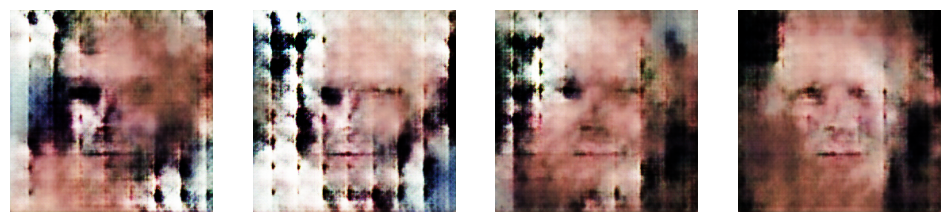

In [32]:
# Test a saved generator model and visualize generated samples
import matplotlib.pyplot as plt

def test_saved_generator(model_path="../models/generator_me.pth", latent_dim=128, num_samples=4, device=None):
    device = get_device()
    gen = Generator(latent_dim=latent_dim).to(device)
    gen.load_state_dict(torch.load(model_path, map_location=device))
    gen.eval()
    with torch.no_grad():
        z = torch.randn(num_samples, latent_dim, device=device)
        samples = gen(z).cpu() * 0.5 + 0.5  # denormalize to [0,1]
    fig, axs = plt.subplots(1, num_samples, figsize=(num_samples*3, 3))
    if num_samples == 1:
        axs = [axs]
    for i, img in enumerate(samples):
        axs[i].imshow(img.permute(1, 2, 0).numpy().clip(0, 1))
        axs[i].axis('off')
    plt.show()


test_saved_generator(model_path="../models/generator_me.pth", latent_dim=128, num_samples=4, device=device)